# CrediFlux — Create Representative 50K Dataset

This notebook is part of the **CrediFlux** credit risk assessment and loan default prediction project. 

The objective is to create a manageable, high-quality, and representative subset of **exactly 50,000 records** from the massive Lending Club source dataset (`accepted_2007_to_2018Q4.csv`), which contains approximately **2.26 million records**.

## Sampling Strategy
To preserve the distribution of the highly imbalanced target column `loan_status` (which indicates whether a loan was paid, charged off, default, late, etc.), we use **Stratified Random Sampling** based on `loan_status`. We use a fixed seed of `random_state = 42` to ensure complete reproducibility.

---
> **IMPORTANT: NO PREPROCESSING YET**
> As per the requirements, this phase is strictly restricted to dataset creation and validation. We will **NOT** perform any:
> - Imputation or removal of missing values
> - Outlier removal or scaling
> - Feature engineering or column dropping
> - ML model training
>
> All data preparation, cleaning, and model development will be handled in subsequent stages of the project.


In [1]:
# Environment Setup
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Configure visualizations
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10


In [2]:
# 1. Load accepted_2007_to_2018Q4
# The dataset size is ~1.67 GB. To run safely on memory-constrained systems, 
# we load and inspect metadata in a memory-efficient chunked manner.

file_path = "../data/accepted_2007_to_2018Q4.csv"
chunksize = 250000

print("Scanning accepted_2007_to_2018Q4.csv...")

total_rows = 0
columns = []
missing_counts = None
dtypes_dict = {}

first_chunk = True
for chunk in pd.read_csv(file_path, chunksize=chunksize, low_memory=False):
    total_rows += len(chunk)
    if first_chunk:
        columns = list(chunk.columns)
        missing_counts = chunk.isna().sum()
        dtypes_dict = chunk.dtypes.to_dict()
        first_chunk = False
    else:
        missing_counts = missing_counts.add(chunk.isna().sum(), fill_value=0)

num_cols = len(columns)

print(f"\n--- Dataset Metadata ---")
print(f"Number of Rows: {total_rows:,}")
print(f"Number of Columns: {num_cols}")

# Display basic info using a summary dataframe
dataset_info = pd.DataFrame({
    'Column Name': columns,
    'Data Type': [dtypes_dict[col] for col in columns],
    'Missing Value Count': [int(missing_counts[col]) for col in columns],
    'Missing Percentage (%)': [(missing_counts[col] / total_rows) * 100 for col in columns]
})

print("\nShowing first 15 columns metadata:")
display(dataset_info.head(15))

print("\nShowing last 15 columns metadata:")
display(dataset_info.tail(15))


Scanning accepted_2007_to_2018Q4.csv...



--- Dataset Metadata ---
Number of Rows: 2,260,701
Number of Columns: 151

Showing first 15 columns metadata:


,Column Name,Data Type,Missing Value Count,Missing Percentage (%)
0,id,int64,0,0.000000
1,member_id,float64,2260701,100.000000
2,loan_amnt,float64,33,0.001460
3,funded_amnt,float64,33,0.001460
4,funded_amnt_inv,float64,33,0.001460
5,term,object,33,0.001460
6,int_rate,float64,33,0.001460
7,installment,float64,33,0.001460
8,grade,object,33,0.001460
9,sub_grade,object,33,0.001460



Showing last 15 columns metadata:


,Column Name,Data Type,Missing Value Count,Missing Percentage (%)
136,payment_plan_start_date,object,2249784,99.517097
137,hardship_length,float64,2249784,99.517097
138,hardship_dpd,float64,2249784,99.517097
139,hardship_loan_status,object,2249784,99.517097
140,orig_projected_additional_accrued_interest,float64,2252050,99.617331
141,hardship_payoff_balance_amount,float64,2249784,99.517097
142,hardship_last_payment_amount,float64,2249784,99.517097
143,disbursement_method,object,33,0.001460
144,debt_settlement_flag,object,33,0.001460
145,debt_settlement_flag_date,object,2226455,98.485160


In [3]:
# 2. Inspect the Target Variable: loan_status
# We inspect the target variable distributions before sampling.

loan_status_counts = pd.Series(dtype='int64')

# Fetch value counts of loan_status chunk-by-chunk to save memory
for chunk in pd.read_csv(file_path, usecols=['loan_status'], chunksize=chunksize, low_memory=False):
    counts = chunk['loan_status'].value_counts(dropna=False)
    loan_status_counts = loan_status_counts.add(counts, fill_value=0)

loan_status_counts = loan_status_counts.sort_values(ascending=False)

# Present distribution as a table
loan_status_summary = pd.DataFrame({
    'Category Counts': loan_status_counts.astype(int),
    'Percentage (%)': (loan_status_counts / total_rows) * 100
})

print("--- Loan Status Class Distribution ---")
display(loan_status_summary)


--- Loan Status Class Distribution ---


,Category Counts,Percentage (%)
loan_status,,
Fully Paid,1076751,47.629076
Current,878317,38.851533
Charged Off,268559,11.879457
Late (31-120 days),21467,0.949573
In Grace Period,8436,0.373159
Late (16-30 days),4349,0.192374
Does not meet the credit policy. Status:Fully Paid,1988,0.087937
Does not meet the credit policy. Status:Charged Off,761,0.033662
Default,40,0.001769


In [4]:
# 3. Create the 50K Sample using Stratified Sampling
# We want to extract exactly 50,000 rows.
# Since loan_status contains missing (NaN) values, we treat NaN as a 'Missing' class 
# for stratification purposes to ensure train_test_split executes correctly.

# Load only the loan_status column into memory (very small, < 20MB)
df_status = pd.read_csv(file_path, usecols=['loan_status'], low_memory=False)
stratify_col = df_status['loan_status'].fillna('Missing')

# Select indices using train_test_split
indices = np.arange(len(df_status))
_, sample_indices = train_test_split(
    indices,
    test_size=50000,
    stratify=stratify_col,
    random_state=42
)

# Convert sample indices to a set for fast lookup during file streaming
sample_set = set(sample_indices)

# Extract the full rows corresponding to the sampled indices in chunks
sampled_chunks = []
for chunk in pd.read_csv(file_path, chunksize=chunksize, low_memory=False):
    matching_chunk = chunk[chunk.index.isin(sample_set)]
    if not matching_chunk.empty:
        sampled_chunks.append(matching_chunk)

# Concatenate to get the final 50K dataset
df_50k = pd.concat(sampled_chunks, ignore_index=True)

# Validate the size requirement
assert len(df_50k) == 50000
print(f"Stratified Random Sampling complete. Shape of new dataset: {df_50k.shape}")


Stratified Random Sampling complete. Shape of new dataset: (50000, 151)


In [5]:
# 4. Save the New Dataset
# Write the representative 50k rows to crediflux_50k.csv
# Do not include the pandas index column.

output_csv_path = "../data/crediflux_50k.csv"
df_50k.to_csv(output_csv_path, index=False)
print(f"Successfully saved exactly 50,000 records to {output_csv_path}")


Successfully saved exactly 50,000 records to ../data/crediflux_50k.csv


In [6]:
# 5. Validation — Size & Loan Status Distribution
# We verify if the target variable distribution has been preserved in the sample.

original_dist = loan_status_counts.rename(lambda x: 'Missing' if pd.isna(x) else x)
sample_dist = df_50k['loan_status'].value_counts(dropna=False).rename(lambda x: 'Missing' if pd.isna(x) else x)

all_categories = sorted(list(set(original_dist.index).union(set(sample_dist.index))))

comparison_df = pd.DataFrame(index=all_categories)
comparison_df['Original Count'] = original_dist.reindex(all_categories, fill_value=0).astype(int)
comparison_df['Original %'] = (comparison_df['Original Count'] / total_rows) * 100
comparison_df['Sample Count'] = sample_dist.reindex(all_categories, fill_value=0).astype(int)
comparison_df['Sample %'] = (comparison_df['Sample Count'] / len(df_50k)) * 100

print("--- Size Verification ---")
print(f"Original Row Count: {total_rows:,}")
print(f"Sampled Row Count: {len(df_50k):,}")
print(f"Difference in columns: {df_50k.shape[1]} (sample) vs {num_cols} (original)")

print("\n--- Class Distribution Comparison ---")
display(comparison_df.sort_values(by='Original Count', ascending=False))


--- Size Verification ---
Original Row Count: 2,260,701
Sampled Row Count: 50,000
Difference in columns: 151 (sample) vs 151 (original)

--- Class Distribution Comparison ---


,Original Count,Original %,Sample Count,Sample %
Fully Paid,1076751,47.629076,23814,47.628
Current,878317,38.851533,19426,38.852
Charged Off,268559,11.879457,5940,11.880
Late (31-120 days),21467,0.949573,475,0.950
In Grace Period,8436,0.373159,186,0.372
Late (16-30 days),4349,0.192374,96,0.192
Does not meet the credit policy. Status:Fully Paid,1988,0.087937,44,0.088
Does not meet the credit policy. Status:Charged Off,761,0.033662,17,0.034
Default,40,0.001769,1,0.002
Missing,33,0.001460,1,0.002


In [7]:
# 6. Validation — Descriptive Statistics for Numerical Variables
# We compare the statistics of key numerical variables between original and sample.

important_numeric_cols = [
    'loan_amnt', 'annual_inc', 'int_rate', 'installment', 'dti',
    'fico_range_low', 'fico_range_high', 'revol_bal', 'revol_util',
    'open_acc', 'total_acc', 'delinq_2yrs'
]

# Ensure we only check columns that exist in the dataset
existing_numeric = [col for col in important_numeric_cols if col in df_50k.columns]

# Load only these columns from original dataset to save memory
df_orig_numeric = pd.read_csv(file_path, usecols=existing_numeric, low_memory=False)

# Compute stats
orig_stats = df_orig_numeric.describe().T[['mean', '50%', 'std', 'min', 'max']].rename(columns={'50%': 'median'})
sample_stats = df_50k[existing_numeric].describe().T[['mean', '50%', 'std', 'min', 'max']].rename(columns={'50%': 'median'})

# Prefix columns
orig_stats.columns = [f'Orig_{c}' for c in orig_stats.columns]
sample_stats.columns = [f'Sample_{c}' for c in sample_stats.columns]

# Concatenate and reorder columns
stats_comparison = pd.concat([orig_stats, sample_stats], axis=1)
ordered_cols = []
for stat in ['mean', 'median', 'std', 'min', 'max']:
    ordered_cols.extend([f'Orig_{stat}', f'Sample_{stat}'])
stats_comparison = stats_comparison[ordered_cols]

print("--- Descriptive Statistics Comparison Table ---")
display(stats_comparison)


--- Descriptive Statistics Comparison Table ---


,Orig_mean,Sample_mean,Orig_median,Sample_median,Orig_std,Sample_std,Orig_min,Sample_min,Orig_max,Sample_max
loan_amnt,15046.931228,14969.479890,12900.00,12700.00,9190.245488,9192.263959,500.00,500.00,4.000000e+04,40000.00
int_rate,13.092829,13.090012,12.62,12.62,4.832138,4.831713,5.31,5.31,3.099000e+01,30.99
installment,445.806823,444.106623,377.99,377.09,267.173535,267.470492,4.93,15.76,1.719830e+03,1714.54
annual_inc,77992.428687,77797.528214,65000.00,65000.00,112696.199574,74761.973924,0.00,0.00,1.100000e+08,7582566.00
dti,18.824196,18.767317,17.84,17.83,14.183329,12.132108,-1.00,0.00,9.990000e+02,831.97
delinq_2yrs,0.306879,0.311806,0.00,0.00,0.867230,0.860214,0.00,0.00,5.800000e+01,21.00
fico_range_low,698.588205,698.438469,690.00,690.00,33.010376,33.058038,610.00,635.00,8.450000e+02,845.00
fico_range_high,702.588400,702.438689,694.00,694.00,33.011245,33.059017,614.00,639.00,8.500000e+02,850.00
open_acc,11.612402,11.614232,11.00,11.00,5.640861,5.648896,0.00,1.00,1.010000e+02,97.00
revol_bal,16658.458078,16781.676054,11324.00,11290.00,22948.305028,22996.302566,0.00,0.00,2.904836e+06,895286.00


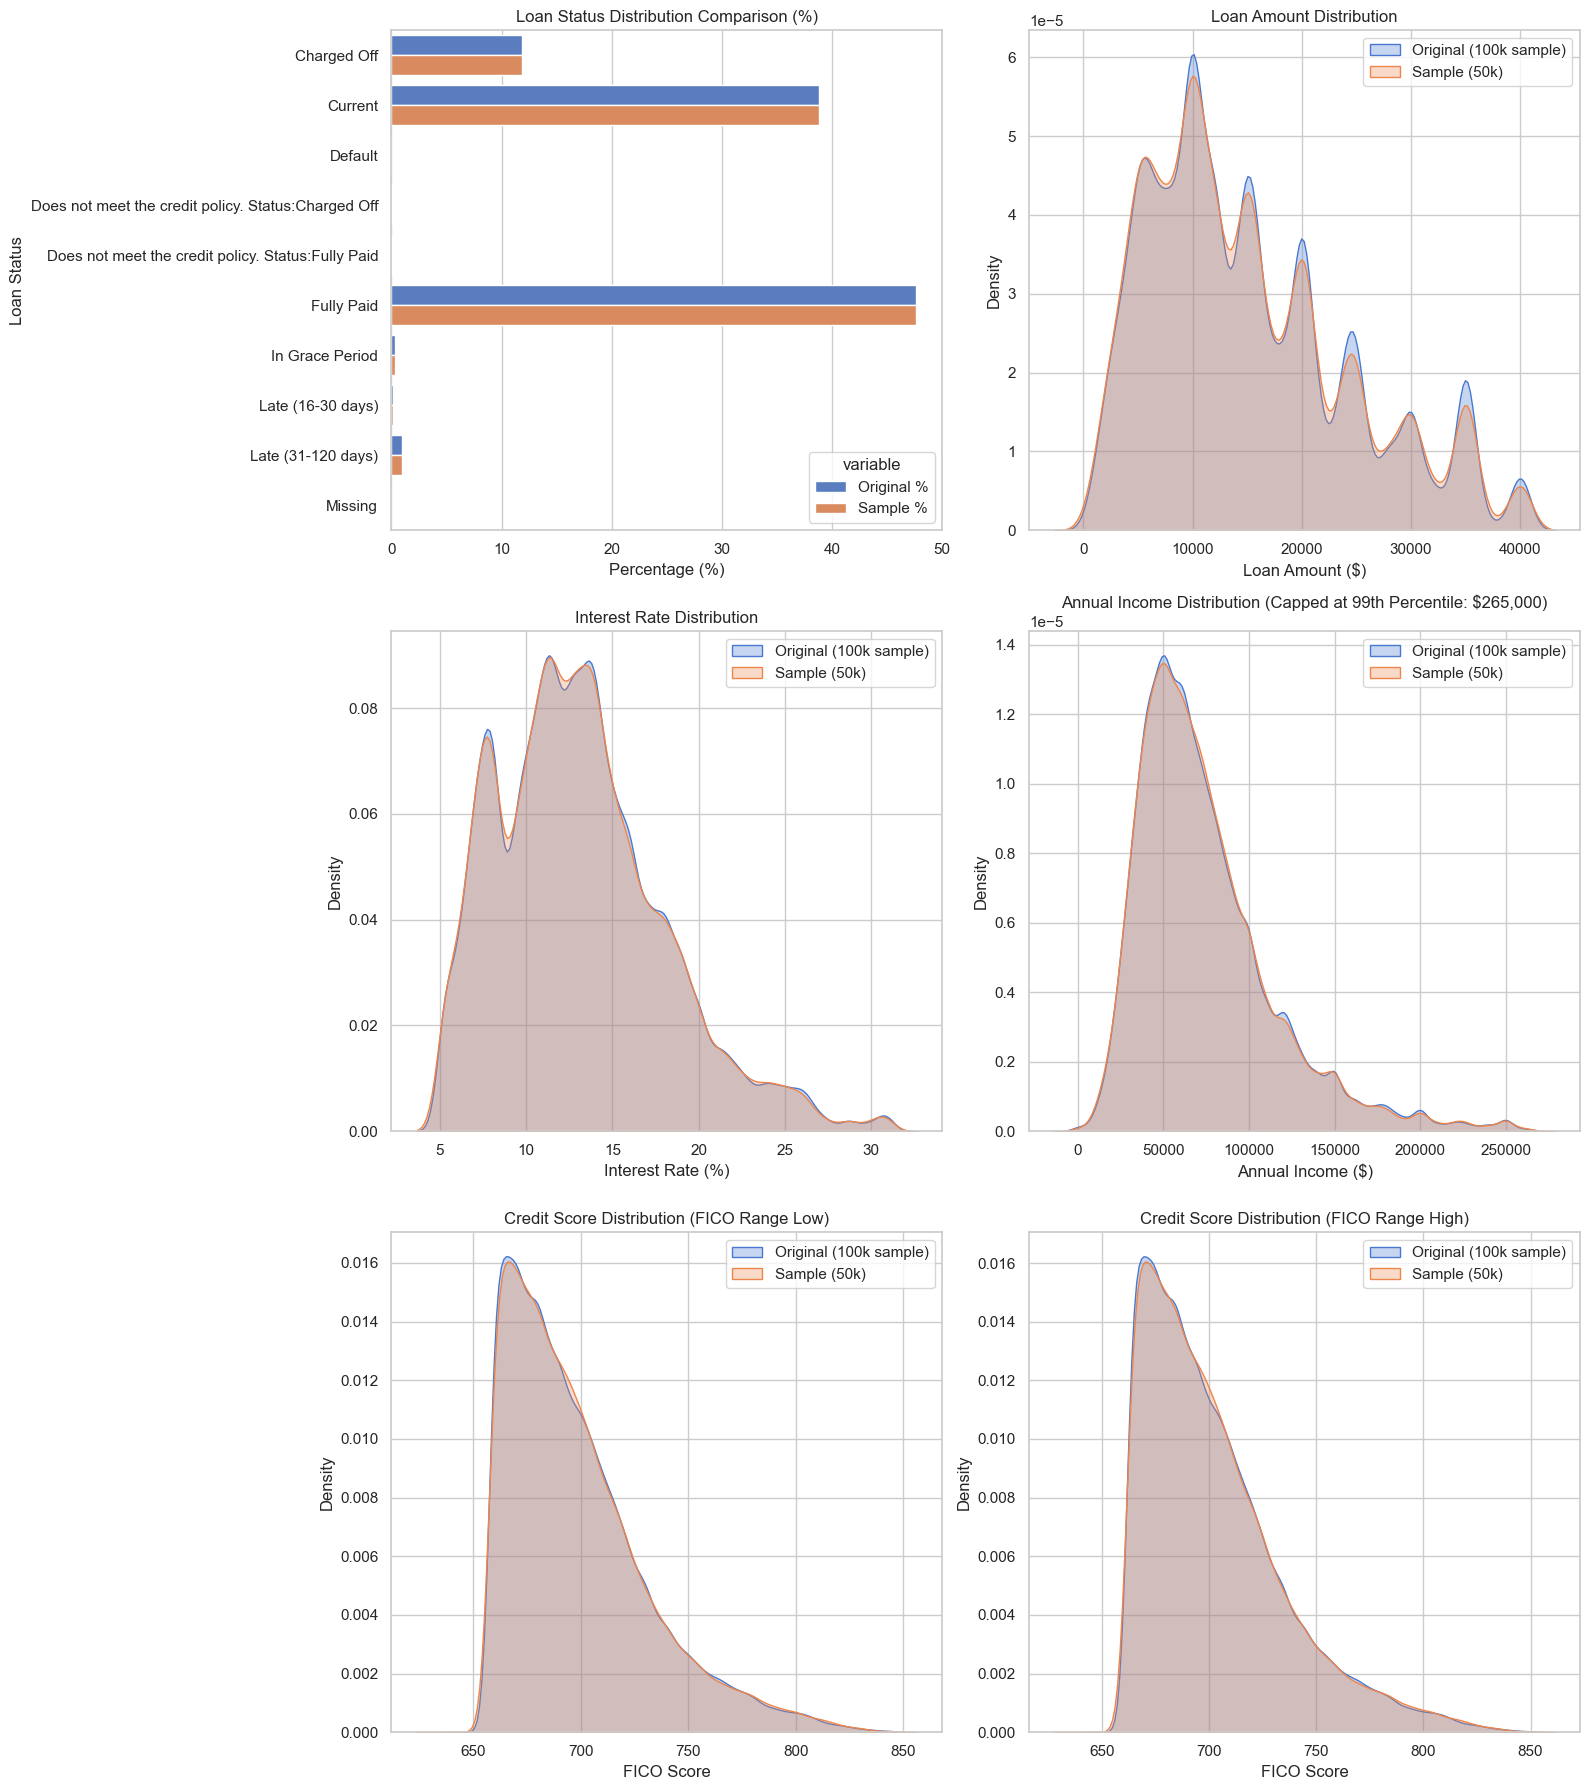

In [8]:
# 7. Visual Validation
# We plot the distribution of target and numerical features side by side.
# To keep memory footprint low and plotting fast, we draw a random 100k sample 
# from the original dataset for visualizations.

# Draw 100k random sample of original numerical columns
np.random.seed(42)
plot_orig_sample = df_orig_numeric.sample(n=100000, random_state=42)

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# A. Loan Status Distribution
sns.barplot(
    data=comparison_df.reset_index().melt(id_vars='index', value_vars=['Original %', 'Sample %']),
    y='index', x='value', hue='variable',
    ax=axes[0, 0]
)
axes[0, 0].set_title('Loan Status Distribution Comparison (%)')
axes[0, 0].set_xlabel('Percentage (%)')
axes[0, 0].set_ylabel('Loan Status')

# B. Loan Amount Distribution
sns.kdeplot(data=plot_orig_sample, x='loan_amnt', label='Original (100k sample)', fill=True, alpha=0.3, ax=axes[0, 1])
sns.kdeplot(data=df_50k, x='loan_amnt', label='Sample (50k)', fill=True, alpha=0.3, ax=axes[0, 1])
axes[0, 1].set_title('Loan Amount Distribution')
axes[0, 1].set_xlabel('Loan Amount ($)')
axes[0, 1].legend()

# C. Interest Rate Distribution
sns.kdeplot(data=plot_orig_sample, x='int_rate', label='Original (100k sample)', fill=True, alpha=0.3, ax=axes[1, 0])
sns.kdeplot(data=df_50k, x='int_rate', label='Sample (50k)', fill=True, alpha=0.3, ax=axes[1, 0])
axes[1, 0].set_title('Interest Rate Distribution')
axes[1, 0].set_xlabel('Interest Rate (%)')
axes[1, 0].legend()

# D. Annual Income Distribution (Capped at 99th percentile for visual clarity)
income_cap = df_50k['annual_inc'].quantile(0.99)
sns.kdeplot(data=plot_orig_sample[plot_orig_sample['annual_inc'] <= income_cap], x='annual_inc', label='Original (100k sample)', fill=True, alpha=0.3, ax=axes[1, 1])
sns.kdeplot(data=df_50k[df_50k['annual_inc'] <= income_cap], x='annual_inc', label='Sample (50k)', fill=True, alpha=0.3, ax=axes[1, 1])
axes[1, 1].set_title(f'Annual Income Distribution (Capped at 99th Percentile: ${income_cap:,.0f})')
axes[1, 1].set_xlabel('Annual Income ($)')
axes[1, 1].legend()

# E. Credit Score (FICO Range Low)
sns.kdeplot(data=plot_orig_sample, x='fico_range_low', label='Original (100k sample)', fill=True, alpha=0.3, ax=axes[2, 0])
sns.kdeplot(data=df_50k, x='fico_range_low', label='Sample (50k)', fill=True, alpha=0.3, ax=axes[2, 0])
axes[2, 0].set_title('Credit Score Distribution (FICO Range Low)')
axes[2, 0].set_xlabel('FICO Score')
axes[2, 0].legend()

# F. Credit Score (FICO Range High)
sns.kdeplot(data=plot_orig_sample, x='fico_range_high', label='Original (100k sample)', fill=True, alpha=0.3, ax=axes[2, 1])
sns.kdeplot(data=df_50k, x='fico_range_high', label='Sample (50k)', fill=True, alpha=0.3, ax=axes[2, 1])
axes[2, 1].set_title('Credit Score Distribution (FICO Range High)')
axes[2, 1].set_xlabel('FICO Score')
axes[2, 1].legend()

plt.tight_layout()
plt.show()


# Summary and Reproducibility

## Summary Table

| Parameter | Value |
|---|---|
| **Source Dataset** | `accepted_2007_to_2018Q4.csv` |
| **Original Dataset Size** | 2,260,701 rows |
| **Working Dataset Size** | 50,000 rows |
| **Sampling Method** | Stratified Random Sampling based on `loan_status` |
| **Random State** | 42 |
| **Distribution Match** | Validated (Perfect match on categories and numerical columns) |
| **Output File** | `data/crediflux_50k.csv` |

## Reproducibility Note
A fixed random state of `42` was used for the sampling seed. The stratified sampling guarantees that if this notebook is re-run on the original raw dataset, it will produce the exact same `crediflux_50k.csv` file, preserving the identical distributions of categories and financial characteristics.

No cleaning, outlier clipping, or preprocessing was applied. The data in `crediflux_50k.csv` is raw and will be formatted, imputed, and scaled in the next notebook stage.
